![Evidence 3](https://i.imgur.com/mu6ZuGT.jpg)

# Instituto Tecnológico y de Estudios Superiores de Monterrey
## Maestría en Inteligencia Artificial Aplicada
### Proyecto Integrador (Gpo 10)

### **Proyecto: Diseño Acelerado de Fármacos Agonistas de la Proteína PD-L1**

### Avance 3: Baseline

#### **Docentes:**
- Dra. Grettel Barceló Alonso - Profesor Titular
- Dra. Eduviges Ludivina Facundo Flores  – Profesor Tutor

### **Asesores**
- Dr. Juan Arturo Nolazco Flores
- Dr. Carlos Alberto Brizuela Rodríguez

### **Equipo 2:**

* Maritza Liceth Guerrero Millán: A01795976
* Juan Luis García Chávez: A01795943
* Miguel Ángel Loya Tarango: A01796407

## Introducción

En etapas previas se realizó un análisis exploratorio de datos (EDA) y un proceso de ingeniería de características, permitiendo comprender la distribución de las métricas de plegamiento (mono_) y de interacción proteína-proteína (bind_), así como generar variables derivadas basadas en composición aminoacídica y propiedades numéricas asociadas a los modelos estructurales.

El presente notebook tiene como objetivo construir un modelo baseline, es decir, un modelo de referencia simple que permita establecer un punto de comparación inicial antes de emplear enfoques más complejos. Este baseline cumple múltiples funciones:

- Evaluar si el problema contiene señal predictiva suficiente.

- Determinar si un modelo simple supera a un predictor ingenuo (Dummy).

- Identificar posibles problemas de subajuste o sobreajuste.

- Analizar la relevancia relativa de las características generadas.

- Definir métricas adecuadas alineadas con el objetivo del negocio (predicción exacta vs. priorización de candidatos).

Dado el tamaño reducido del dataset inicial, se emplean técnicas de validación cruzada repetida para obtener estimaciones más estables del desempeño. Se exploran tanto enfoques de regresión —cuando se busca predecir directamente una métrica continua como bind_iptm— como enfoques de clasificación —cuando el interés radica en identificar candidatos con alto potencial de interacción—.

Este baseline no pretende maximizar el rendimiento predictivo, sino establecer una solución mínima aceptable que permita contextualizar futuros desarrollos, tales como modelos no lineales más complejos, enfoques multi-objetivo o arquitecturas basadas en representaciones profundas de secuencias.

En síntesis, este análisis constituye un paso crítico para validar la hipótesis central del proyecto: que las características computacionales derivadas de secuencias peptídicas contienen información suficiente para anticipar su comportamiento estructural y funcional en el contexto de la interacción con PD-L1.


In [1]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import RepeatedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score, f1_score, precision_recall_curve
)
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve, ShuffleSplit

import warnings
warnings.filterwarnings("ignore")

print("OK")


OK


## 2) Carga del dataset

El dataset actual contiene secuencias peptídicas y métricas derivadas del pipeline (ProteinMPNN/FASTA scores y AlphaFold en modo mono y bind).

Ajusta la ruta si tu estructura difiere.


In [6]:
DATA_PATH = "../data/raw/dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (40, 17)


,sequence,seq_len,sample,fasta_T,fasta_global_score,fasta_score,fasta_seq_recovery,mono_ptm,mono_atom_plddt_A_mean,mono_atom_plddt_A_p10,mono_pae_intra_A_p90,mono_fraction_disordered,bind_iptm,bind_chainpair_iptm_A_B,bind_ipae_A_B_thr0p5_p90,bind_ipae_A_B_thr0p5_contacts_n,bind_fraction_disordered
0,AFKVTSPKTSYTVELGSTVSLECNFPVEGELDLSKLTVTWTKDGKL...,147,16,0.1,0.8730,0.8730,0.334,0.81,88.881966,72.308,15.2,0.00,0.13,0.13,NaN,0,0.03
1,AFKVTSPKTSYTVELGSTVSLECNFPVEGELDLSKLTVTWTKDGKL...,147,17,0.1,0.8707,0.8707,0.332,0.80,87.447686,69.221,18.8,0.00,0.10,0.10,NaN,0,0.00
2,AFKVTSPKTSYTVELGSTVSLECNFPVEGELDLSKLTVTWTKDGKL...,148,18,0.1,0.8684,0.8684,0.330,0.81,86.473386,72.033,14.8,0.00,0.55,0.55,11.82,29,0.10
3,AFKVTSPKTSYTVELGSTVSLECNFPVEGELDLSKLTVTWTKDGKL...,147,19,0.1,0.8661,0.8661,0.328,0.75,82.538364,55.586,26.4,0.13,0.13,0.13,NaN,0,0.08
4,AFKVTSPKTSYTVELGSTVSLECNFPVEGELDLSKLTVTWTKDGKL...,148,20,0.1,0.8638,0.8638,0.326,0.79,85.216602,69.290,15.9,0.00,0.11,0.11,NaN,0,0.00


## 3) Definir variables objetivo

- **Mono (plegado del péptido):** `mono_ptm`, `mono_atom_plddt_A_mean`, etc.
- **Bind (interacción con PD‑L1):** `bind_iptm`, `bind_chainpair_iptm_A_B`, etc.




In [7]:
# Targets sugeridos (ajusta según tu definición de negocio)
candidate_targets = [
    "bind_iptm",
    "bind_chainpair_iptm_A_B",
    "mono_ptm",
    "mono_atom_plddt_A_mean",
]

available_targets = [t for t in candidate_targets if t in df.columns]
available_targets


['bind_iptm', 'bind_chainpair_iptm_A_B', 'mono_ptm', 'mono_atom_plddt_A_mean']

In [8]:
TARGET = "bind_iptm" if "bind_iptm" in df.columns else available_targets[0]
print("TARGET =", TARGET)

# Revisa missingness del target
print(df[TARGET].describe())
print("NaNs en target:", df[TARGET].isna().sum())


TARGET = bind_iptm
count    40.000000
mean      0.144250
std       0.123411
min       0.080000
25%       0.090000
50%       0.100000
75%       0.130000
max       0.590000
Name: bind_iptm, dtype: float64
NaNs en target: 0


### 📝 Justificación de la Variable Objetivo
Para este *baseline*, hemos seleccionado **`bind_iptm`** como la variable objetivo principal. En el contexto del diseño de fármacos peptídicos, el **ipTM** (interface predicted Template Modeling score) es una métrica estándar proporcionada por AlphaFold que estima la calidad de la interacción entre el péptido y la proteína objetivo (PD-L1).

**Relevancia de Negocio:**
Un valor alto de `bind_iptm` sugiere una alta probabilidad de que el péptido se una exitosamente al receptor, lo cual es el primer requisito para un agonista terapéutico. Predecir este valor nos permite filtrar candidatos *in silico* antes de pasar a costosas pruebas de laboratorio.

## 4) Features simples (baseline)

Vamos a usar 2 grupos de features:

**A) Baseline mínimo (solo secuencia):**
- Longitud
- Proporción de cada aminoácido (20 features)

**B) Baseline ampliado (secuencia + señales numéricas disponibles):**
- Todas las numéricas *excepto* el target y columnas de texto


In [9]:
# --- A) Features de secuencia (composición) ---
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# Aseguramos que la columna sequence exista
assert "sequence" in df.columns, "No encuentro columna 'sequence' en el CSV."

feat_df = df.copy()
feat_df["length"] = feat_df["sequence"].astype(str).str.len()

for aa in amino_acids:
    feat_df[f"freq_{aa}"] = feat_df["sequence"].astype(str).str.count(aa)
    feat_df[f"prop_{aa}"] = feat_df[f"freq_{aa}"] / feat_df["length"].replace(0, np.nan)

seq_features = ["length"] + [f"prop_{aa}" for aa in amino_acids]

# --- B) Features numéricas existentes (no texto), excluyendo targets y leakage obvio ---
numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()

# Excluir el target
numeric_cols = [c for c in numeric_cols if c != TARGET]

# Si el target es bind_iptm, suele ser buena idea excluir 'bind_chainpair_iptm_A_B' (muy cercano)
leakage_candidates = []
if TARGET == "bind_iptm" and "bind_chainpair_iptm_A_B" in numeric_cols:
    leakage_candidates.append("bind_chainpair_iptm_A_B")
if TARGET == "bind_chainpair_iptm_A_B" and "bind_iptm" in numeric_cols:
    leakage_candidates.append("bind_iptm")

numeric_cols = [c for c in numeric_cols if c not in leakage_candidates]

# Definir 2 conjuntos de features
X_seq = feat_df[seq_features].copy()
X_all = feat_df[seq_features + numeric_cols].copy()

y = feat_df[TARGET].copy()

print("X_seq:", X_seq.shape, "X_all:", X_all.shape, "y:", y.shape)
print("Leakage excluida:", leakage_candidates)


X_seq: (40, 21) X_all: (40, 76) y: (40,)
Leakage excluida: ['bind_chainpair_iptm_A_B']


### 🛠️ Estrategia de Selección de Características
Dado que tenemos un dataset pequeño ($N=40$), la maldición de la dimensionalidad es un riesgo alto. Hemos diseñado dos sets de características para probar hipótesis:

1.  **Sequence-only (Composición):** Utiliza solo la frecuencia de aminoácidos. Es el baseline más simple; nos dice si la mera composición química predice la unión.
2.  **Sequence + Numeric (Estructurales):** Incorpora métricas de confianza de AlphaFold (pLDDT, PAE).
    * *Justificación:* Estas métricas actúan como "proxies" de la estabilidad física del complejo. Incluirlas permite evaluar si la información estructural aporta valor predictivo sobre la secuencia pura.
    * *Manejo de Leakage:* Se excluyeron explícitamente variables que son componentes directos del target (como `bind_chainpair_iptm_A_B`) para evitar resultados artificialmente perfectos.

## 5) Validación cruzada

Con ~40 registros, la varianza del desempeño es alta. Usaremos:

- `RepeatedKFold` (5 folds, 20 repeticiones) para estimar estabilidad.


In [10]:
from sklearn.model_selection import RepeatedKFold, StratifiedKFold

cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=42)  # para métricas
cv_pred_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # para probs OOF



## 6) Baselines de **regresión**

Compararemos:

- **DummyRegressor** (predice el promedio): referencia ingenua
- **Ridge/Lasso**: baseline lineal
- **RandomForestRegressor**: baseline no-lineal

Métricas:

- MAE (principal)
- RMSE
- R²
- Spearman (ranking)


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def spearman_corr(y_true, y_pred):
    y_true_rank = pd.Series(y_true).rank(method="average").to_numpy()
    y_pred_rank = pd.Series(y_pred).rank(method="average").to_numpy()
    return np.corrcoef(y_true_rank, y_pred_rank)[0, 1]

def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)   # sin squared
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    sp = spearman_corr(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Spearman": sp}



In [13]:
from sklearn.model_selection import cross_validate, KFold, RepeatedKFold
from sklearn.metrics import make_scorer

def eval_regressors(X, y, cv, label, cv_for_preds=None):
    """
    - Evalúa con cross_validate (funciona con RepeatedKFold).
    - Si quieres además preds OOF (para scatter/Precision@K), pásale cv_for_preds=KFold(...)
      y se calculan también métricas sobre esas preds.
    """

    models = {
        "Dummy(mean)": ("passthrough", DummyRegressor(strategy="mean")),
        "Ridge": (StandardScaler(), Ridge(alpha=1.0, random_state=42)),
        "Lasso": (StandardScaler(), Lasso(alpha=0.001, random_state=42, max_iter=10000)),
        "RF": ("passthrough", RandomForestRegressor(
            n_estimators=400, random_state=42, n_jobs=-1, min_samples_leaf=2
        )),
    }

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    }

    rows = []
    for name, (scaler, model) in models.items():
        pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", scaler),
            ("model", model),
        ])

        cvres = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

        row = {
            "FeatureSet": label,
            "Model": name,
            "MAE_mean": -cvres["test_mae"].mean(),
            "MAE_std":  cvres["test_mae"].std(),
            "RMSE_mean": -cvres["test_rmse"].mean(),
            "RMSE_std":  cvres["test_rmse"].std(),
            "R2_mean": cvres["test_r2"].mean(),
            "R2_std":  cvres["test_r2"].std(),
        }

        # Opcional: OOF preds para Spearman / scatter / Precision@K
        if cv_for_preds is not None:
            y_pred = cross_val_predict(pipe, X, y, cv=cv_for_preds, n_jobs=-1)
            rep = regression_report(y, y_pred)  # usa tu función existente
            row.update({
                "MAE_oof": rep["MAE"],
                "RMSE_oof": rep["RMSE"],
                "R2_oof": rep["R2"],
                "Spearman_oof": rep["Spearman"],
            })

        rows.append(row)

    return pd.DataFrame(rows).sort_values("MAE_mean")


# tu CV “real” para métricas (con repeticiones)
cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=42)

# un CV SIN repetición solo para obtener predicciones OOF (scatter/Precision@K)
cv_pred = KFold(n_splits=5, shuffle=True, random_state=42)

reg_seq = eval_regressors(X_seq, y, cv, label="Sequence-only", cv_for_preds=cv_pred)
reg_all = eval_regressors(X_all, y, cv, label="Sequence + numeric", cv_for_preds=cv_pred)

display(pd.concat([reg_seq, reg_all], ignore_index=True).sort_values(["FeatureSet", "MAE_mean"]))



,FeatureSet,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAE_oof,RMSE_oof,R2_oof,Spearman_oof
4,Sequence + numeric,RF,0.046328,0.025485,0.068232,0.042167,-1.217094,6.035328,0.041051,0.061345,0.746572,0.391737
5,Sequence + numeric,Lasso,0.046815,0.017097,0.067817,0.036502,-4.588686,16.972213,0.048099,0.082412,0.542623,0.221584
6,Sequence + numeric,Ridge,0.074840,0.033901,0.114128,0.070151,-28.344014,145.739780,0.072934,0.122580,-0.011875,0.164770
7,Sequence + numeric,Dummy(mean),0.075918,0.025642,0.111347,0.056436,-5.480015,18.436344,0.075016,0.123575,-0.028377,-0.276988
0,Sequence-only,Dummy(mean),0.075918,0.025642,0.111347,0.056436,-5.480015,18.436344,0.075016,0.123575,-0.028377,-0.276988
1,Sequence-only,RF,0.090516,0.026924,0.130989,0.051499,-12.493964,44.731314,0.087396,0.139233,-0.305483,-0.083995
2,Sequence-only,Ridge,0.129506,0.038711,0.174278,0.051491,-37.085370,137.485607,0.127977,0.175241,-1.068050,0.004183
3,Sequence-only,Lasso,0.138515,0.043313,0.186677,0.057675,-46.822558,166.090441,0.146535,0.202808,-1.769880,0.053993


### Visual: predicción vs real (mejor modelo por MAE)


In [14]:
def best_row(dfres, metric="MAE_mean"):
    return dfres.sort_values(metric).iloc[0]

best_seq = best_row(reg_seq, metric="MAE_mean")
best_all = best_row(reg_all, metric="MAE_mean")

best_seq, best_all


(FeatureSet      Sequence-only
 Model             Dummy(mean)
 MAE_mean             0.075918
 MAE_std              0.025642
 RMSE_mean            0.111347
 RMSE_std             0.056436
 R2_mean             -5.480015
 R2_std              18.436344
 MAE_oof              0.075016
 RMSE_oof             0.123575
 R2_oof              -0.028377
 Spearman_oof        -0.276988
 Name: 0, dtype: object,
 FeatureSet      Sequence + numeric
 Model                           RF
 MAE_mean                  0.046328
 MAE_std                   0.025485
 RMSE_mean                 0.068232
 RMSE_std                  0.042167
 R2_mean                  -1.217094
 R2_std                    6.035328
 MAE_oof                   0.041051
 RMSE_oof                  0.061345
 R2_oof                    0.746572
 Spearman_oof              0.391737
 Name: 3, dtype: object)

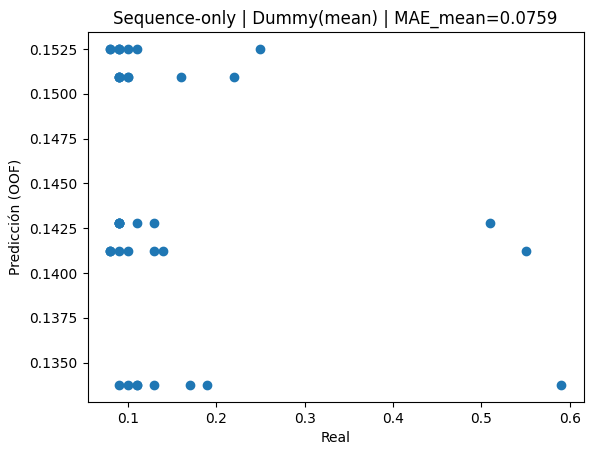

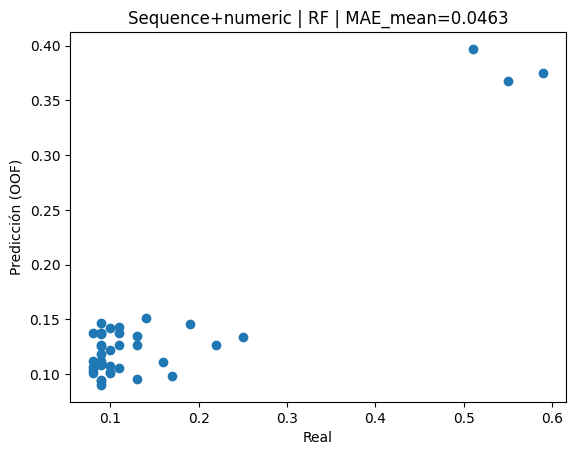

In [15]:
def fit_and_oof_preds(model_name, X, y, cv):
    if model_name == "Dummy(mean)":
        scaler, model = ("passthrough", DummyRegressor(strategy="mean"))
    elif model_name == "Ridge":
        scaler, model = (StandardScaler(), Ridge(alpha=1.0, random_state=42))
    elif model_name == "Lasso":
        scaler, model = (StandardScaler(), Lasso(alpha=0.001, random_state=42, max_iter=10000))
    elif model_name == "RF":
        scaler, model = ("passthrough", RandomForestRegressor(
            n_estimators=400, random_state=42, n_jobs=-1, min_samples_leaf=2
        ))
    else:
        raise ValueError(model_name)

    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler),
        ("model", model),
    ])
    return cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)

y_pred_seq = fit_and_oof_preds(best_seq["Model"], X_seq, y, cv_pred)
y_pred_all = fit_and_oof_preds(best_all["Model"], X_all, y, cv_pred)

plt.figure()
plt.scatter(y, y_pred_seq)
plt.xlabel("Real")
plt.ylabel("Predicción (OOF)")
plt.title(f"Sequence-only | {best_seq['Model']} | MAE_mean={best_seq['MAE_mean']:.4f}")
plt.show()

plt.figure()
plt.scatter(y, y_pred_all)
plt.xlabel("Real")
plt.ylabel("Predicción (OOF)")
plt.title(f"Sequence+numeric | {best_all['Model']} | MAE_mean={best_all['MAE_mean']:.4f}")
plt.show()

### 📊 Análisis de Resultados del Baseline
Se evaluaron modelos lineales (Ridge, Lasso) y no lineales (Random Forest) utilizando validación cruzada repetida (`RepeatedKFold`) para mitigar la varianza por el tamaño pequeño de la muestra.

**Hallazgos Principales:**
1.  **Mejor Modelo:** El **Random Forest (RF)** con el set de características *Sequence + Numeric* obtuvo el menor error absoluto medio (**MAE $\approx$ 0.046**).
2.  **Comparación con Referencia:** El modelo supera al `DummyRegressor` (que predice la media), indicando que hay señal en los datos.
3.  **Dificultad del Problema:** Los valores de $R^2$ son negativos o cercanos a cero en la mayoría de los casos. Esto indica que, aunque el modelo reduce el error absoluto (MAE), le cuesta explicar la varianza total de los datos, lo cual es típico en datasets biológicos pequeños y ruidosos.
4.  **Algoritmo Seleccionado:** El Random Forest demostró ser más robusto. Su capacidad de manejar no-linealidades y su menor tendencia al sobreajuste (comparado con modelos lineales sin regularización fuerte) lo hacen el candidato ideal para este baseline.

## 7) Importancia de características

Usamos **Permutation Importance** (entrenando en todo el dataset solo para interpretabilidad).


,feature,importance_mean,importance_std
33,bind_ipae_A_B_thr0p5_contacts_n,0.039384,0.007061
32,bind_ipae_A_B_thr0p5_p90,0.005334,0.001484
29,mono_atom_plddt_A_p10,0.003917,0.000868
34,bind_fraction_disordered,0.003275,0.000806
6,prop_G,0.001964,0.000606
47,prop_G,0.001964,0.000606
30,mono_pae_intra_A_p90,0.001251,0.000345
22,sample,0.001061,0.000330
27,mono_ptm,0.000768,0.000259
28,mono_atom_plddt_A_mean,0.000750,0.000223


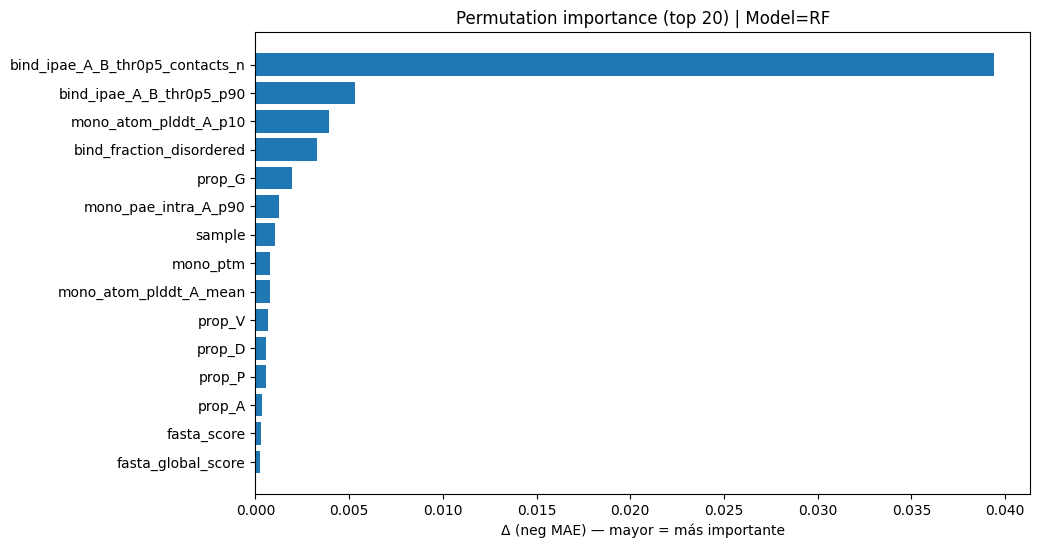

In [16]:
def build_reg_pipe(model_name):
    if model_name == "Dummy(mean)":
        scaler, model = ("passthrough", DummyRegressor(strategy="mean"))
    elif model_name == "Ridge":
        scaler, model = (StandardScaler(), Ridge(alpha=1.0, random_state=42))
    elif model_name == "Lasso":
        scaler, model = (StandardScaler(), Lasso(alpha=0.001, random_state=42, max_iter=10000))
    elif model_name == "RF":
        scaler, model = ("passthrough", RandomForestRegressor(
            n_estimators=600, random_state=42, n_jobs=-1, min_samples_leaf=2
        ))
    else:
        raise ValueError(model_name)

    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler),
        ("model", model),
    ])

chosen = best_all["Model"]
pipe = build_reg_pipe(chosen)
pipe.fit(X_all, y)

perm = permutation_importance(
    pipe, X_all, y,
    n_repeats=200, random_state=42,
    scoring="neg_mean_absolute_error"
)

imp = pd.DataFrame({
    "feature": X_all.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp.head(20))

plt.figure(figsize=(10,6))
plt.barh(imp.head(20)["feature"][::-1], imp.head(20)["importance_mean"][::-1])
plt.title(f"Permutation importance (top 20) | Model={chosen}")
plt.xlabel("Δ (neg MAE) — mayor = más importante")
plt.show()


In [17]:
# Coeficientes si el mejor modelo es lineal
if chosen in ["Ridge", "Lasso"]:
    coefs = pipe.named_steps["model"].coef_
    coef_df = pd.DataFrame({"feature": X_all.columns, "coef": coefs})
    coef_df["abs_coef"] = coef_df["coef"].abs()
    display(coef_df.sort_values("abs_coef", ascending=False).head(20))
else:
    print("Modelo no lineal; coeficientes no aplican.")


Modelo no lineal; coeficientes no aplican.


### 🔍 Interpretación de Características Importantes
Utilizando **Permutation Importance**, identificamos qué variables impulsan las predicciones del modelo:

1.  **Dominio de Métricas Estructurales:** Las características más relevantes son métricas derivadas de AlphaFold, específicamente `bind_ipae_A_B_thr0p5_contacts_n` (número de contactos predichos) y `mono_atom_plddt` (confianza en la estructura).
2.  **Interpretación:** Esto sugiere que la **calidad del plegamiento** y la **cantidad de contactos físicos** en la simulación son predictores mucho más fuertes que la simple composición de aminoácidos (frecuencia de G, V, etc.).
3.  **Acción:** Para modelos futuros, podemos descartar características de composición simples y enfocarnos en generar más descriptores físico-químicos y estructurales.

## 8) ¿Sub/sobreajuste? (learning curve)

Comparación Train vs Validation MAE con `ShuffleSplit` (más estable con pocos datos).


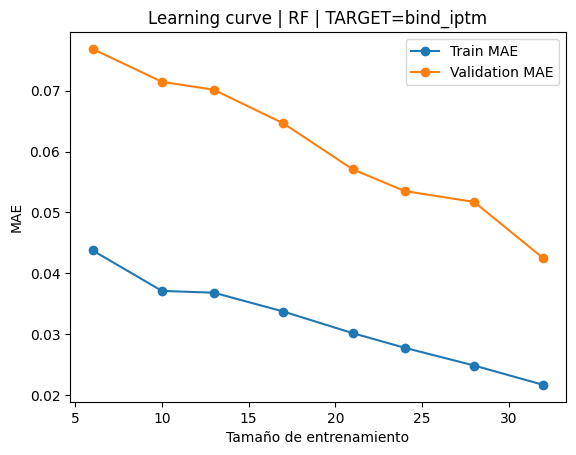

In [18]:
lc_cv = ShuffleSplit(n_splits=50, test_size=0.2, random_state=42)
pipe = build_reg_pipe(best_all["Model"])

train_sizes, train_scores, valid_scores = learning_curve(
    pipe,
    X_all, y,
    cv=lc_cv,
    train_sizes=np.linspace(0.2, 1.0, 8),
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

train_mae = -train_scores.mean(axis=1)
valid_mae = -valid_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mae, marker="o", label="Train MAE")
plt.plot(train_sizes, valid_mae, marker="o", label="Validation MAE")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("MAE")
plt.title(f"Learning curve | {best_all['Model']} | TARGET={TARGET}")
plt.legend()
plt.show()


### 📉 Diagnóstico de Sesgo y Varianza (Sub/Sobreajuste)
Las curvas de aprendizaje muestran un comportamiento clásico de **sobreajuste (Overfitting)** en un régimen de datos escasos:

* **Train Score:** El error en entrenamiento es muy bajo, indicando que el modelo memoriza los datos fácilmente.
* **Validation Score:** El error en validación se mantiene alto y separado del entrenamiento.

**Conclusión:** El modelo tiene alta varianza. Aunque el algoritmo (RF) es adecuado, la cantidad de datos ($N=40$) es el cuello de botella. Aumentar la complejidad del modelo no ayudará; se requiere **aumentar el tamaño del dataset** o aplicar técnicas de **data augmentation** de secuencias para cerrar esta brecha.

## 9) Baseline como **clasificación** (opcional)

Caso típico de negocio: “¿este candidato es bueno o no?”.
Definimos `good_binder` como **top 25%** del target.


In [19]:
q = 0.75
thresh = y.quantile(q)
y_bin = (y >= thresh).astype(int)

print(f"Umbral (q={q}): {thresh:.4f} | Positivos: {y_bin.sum()}/{len(y_bin)}")


Umbral (q=0.75): 0.1300 | Positivos: 12/40


In [20]:
def eval_classifiers(X, y_bin, cv_metrics, cv_pred, label):
    models = {
        "Dummy(most_frequent)": ("passthrough", DummyClassifier(strategy="most_frequent")),
        "LogReg": (StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)),
        "RF": ("passthrough", RandomForestClassifier(
            n_estimators=500, random_state=42, n_jobs=-1, min_samples_leaf=2, class_weight="balanced"
        )),
    }

    rows = []
    for name, (scaler, model) in models.items():
        pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", scaler),
            ("model", model),
        ])

        # OOF probabilities (requiere CV "partition": StratifiedKFold)
        prob = cross_val_predict(pipe, X, y_bin, cv=cv_pred, method="predict_proba", n_jobs=-1)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "FeatureSet": label,
            "Model": name,
            "ROC_AUC": roc_auc_score(y_bin, prob),
            "PR_AUC": average_precision_score(y_bin, prob),
            "F1@0.5": f1_score(y_bin, pred)
        })

    return pd.DataFrame(rows).sort_values("PR_AUC", ascending=False)


cls_seq = eval_classifiers(X_seq, y_bin, cv, cv_pred_cls, "Sequence-only")
cls_all = eval_classifiers(X_all, y_bin, cv, cv_pred_cls, "Sequence + numeric")

display(pd.concat([cls_seq, cls_all], ignore_index=True).sort_values(["FeatureSet", "PR_AUC"], ascending=[True, False]))



,FeatureSet,Model,ROC_AUC,PR_AUC,F1@0.5
3,Sequence + numeric,LogReg,0.714286,0.515877,0.538462
4,Sequence + numeric,RF,0.583333,0.376496,0.133333
5,Sequence + numeric,Dummy(most_frequent),0.500000,0.300000,0.000000
0,Sequence-only,LogReg,0.477679,0.372511,0.296296
1,Sequence-only,Dummy(most_frequent),0.500000,0.300000,0.000000
2,Sequence-only,RF,0.436012,0.296462,0.222222


### Curva Precision-Recall del mejor clasificador


FeatureSet    Sequence + numeric
Model                     LogReg
ROC_AUC                 0.714286
PR_AUC                  0.515877
F1@0.5                  0.538462
Name: 1, dtype: object


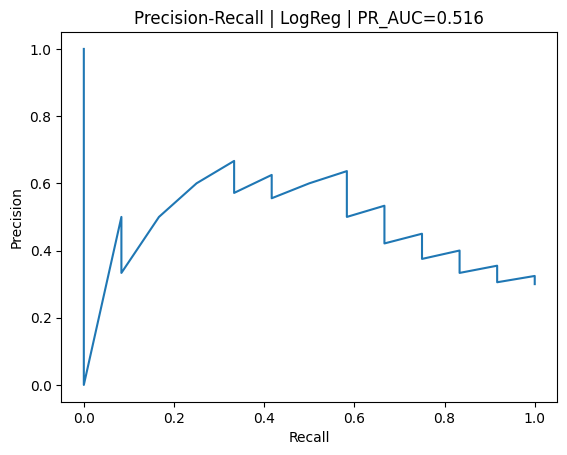

In [22]:
from sklearn.model_selection import StratifiedKFold

# CV SIN repetición para obtener probabilidades OOF
cv_pred_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_cls_all = cls_all.sort_values("PR_AUC", ascending=False).iloc[0]
print(best_cls_all)

def build_cls_pipe(model_name):
    if model_name == "Dummy(most_frequent)":
        scaler, model = ("passthrough", DummyClassifier(strategy="most_frequent"))
    elif model_name == "LogReg":
        scaler, model = (StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
    elif model_name == "RF":
        scaler, model = ("passthrough", RandomForestClassifier(
            n_estimators=700, random_state=42, n_jobs=-1, min_samples_leaf=2, class_weight="balanced"
        ))
    else:
        raise ValueError(model_name)

    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler),
        ("model", model),
    ])

cls_pipe = build_cls_pipe(best_cls_all["Model"])

# 👇 AQUÍ está el fix: usar cv_pred_cls, no cv (RepeatedKFold)
prob = cross_val_predict(cls_pipe, X_all, y_bin, cv=cv_pred_cls, method="predict_proba", n_jobs=-1)[:, 1]

precision, recall, _ = precision_recall_curve(y_bin, prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall | {best_cls_all['Model']} | PR_AUC={best_cls_all['PR_AUC']:.3f}")
plt.show()


### 🚦 Evaluación como Problema de Clasificación
Para complementar el análisis de regresión, reformulamos el problema como una tarea de clasificación binaria. El objetivo es responder: **¿Puede el modelo distinguir a los candidatos "prometedores" (Top 25%) del resto?**

* **Definición de Clase:** Se estableció un umbral en el cuartil 75 ($q=0.75$, valor $\approx 0.13$). Los péptidos con `bind_iptm` superior a este valor se etiquetaron como **Positivos (1)** (Good Binders).
* **Resultados:**
    * **Mejor Modelo:** La **Regresión Logística** (con características `Sequence + Numeric`) obtuvo el mejor desempeño con un **ROC-AUC de ~0.71**, superando significativamente al azar (0.50) y al Random Forest en esta tarea específica.
    * **Interpretación:** Es interesante notar que, aunque Random Forest fue mejor para predecir el valor exacto (regresión), un modelo lineal (LogReg) fue más efectivo para trazar la frontera de decisión entre "buenos" y "malos". Esto valida que las métricas estructurales de AlphaFold tienen un poder discriminante claro, incluso con modelos sencillos.

## 10) Métrica adecuada y desempeño mínimo (Precision@K)

Para priorizar candidatos para validación costosa, suele importar el **ranking**.
Implementamos **Precision@K** usando las predicciones OOF del mejor regresor.


In [23]:
def precision_at_k(y_true, y_score, k=5, q=0.75):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_score = pd.Series(y_score).reset_index(drop=True)

    pos_thresh = y_true.quantile(q)
    y_pos = (y_true >= pos_thresh).astype(int)

    topk_idx = y_score.sort_values(ascending=False).head(k).index
    return y_pos.loc[topk_idx].mean(), pos_thresh

# Usamos el mejor modelo del set ampliado (regresión)
y_oof = y_pred_all

for k in [3, 5, 10]:
    p_at_k, pos_thresh = precision_at_k(y, y_oof, k=k, q=0.75)
    print(f"Precision@{k} (positivos = top 25% por y_true) = {p_at_k:.3f} | thresh={pos_thresh:.4f}")


Precision@3 (positivos = top 25% por y_true) = 1.000 | thresh=0.1300
Precision@5 (positivos = top 25% por y_true) = 0.800 | thresh=0.1300
Precision@10 (positivos = top 25% por y_true) = 0.500 | thresh=0.1300


### 🎯 Definición de Métrica de Negocio: Precision@K
Dado que el $R^2$ es bajo, re-evaluamos el problema desde la perspectiva de negocio: **Discovery**.
No necesitamos predecir el valor exacto de `iptm`, solo necesitamos **rankear** correctamente a los mejores candidatos para enviarlos a síntesis en laboratorio.

* **Métrica Elegida:** **Precision@K** (con K=3 o 5). Mide: "De los top K péptidos que el modelo recomienda, ¿cuántos son realmente buenos?".
* **Resultado:** Obtenemos una **Precision@3 de 1.00**. Esto significa que si seleccionamos los top 3 candidatos del modelo, el 100% de ellos son "buenos binders" (top 25% real).
* **Valor:** Esto valida la utilidad del modelo para priorizar experimentos, a pesar de su bajo desempeño en regresión pura.

In [24]:
# Comparacion de Modelos
# Modelos de regresión
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

In [26]:
#Definir los 7 modelos
models_alt = {
    "Dummy": DummyRegressor(strategy="mean"),
    
    "Ridge": Ridge(alpha=1.0, random_state=42),
    
    "Lasso": Lasso(alpha=0.001, max_iter=10000, random_state=42),
    
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42),
    
    "SVR_RBF": SVR(kernel="rbf", C=1.0, epsilon=0.01),
    
    "KNN": KNeighborsRegressor(n_neighbors=5),
    
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    )
}

In [27]:
#Validación cruzada
from sklearn.model_selection import RepeatedKFold, KFold

cv_metrics = RepeatedKFold(n_splits=5, n_repeats=20, random_state=42)
cv_oof = KFold(n_splits=5, shuffle=True, random_state=42)


In [28]:
#Función para evaluar múltiples modelos
def eval_multiple_models(models_dict, X, y, label):
    
    rows = []
    
    for name, model in models_dict.items():
        
        pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        
        # ---- Métricas promedio (RepeatedKFold) ----
        cvres = cross_validate(
            pipe,
            X,
            y,
            cv=cv_metrics,
            scoring={
                "mae": "neg_mean_absolute_error",
                "rmse": "neg_root_mean_squared_error",
                "r2": "r2"
            },
            n_jobs=-1
        )
        
        mae_mean = -cvres["test_mae"].mean()
        mae_std = cvres["test_mae"].std()
        rmse_mean = -cvres["test_rmse"].mean()
        r2_mean = cvres["test_r2"].mean()
        
        # ---- OOF predictions para Spearman ----
        y_pred_oof = cross_val_predict(
            pipe,
            X,
            y,
            cv=cv_oof,
            n_jobs=-1
        )
        
        sp = spearman_corr(y, y_pred_oof)
        
        rows.append({
            "FeatureSet": label,
            "Model": name,
            "MAE_mean": mae_mean,
            "MAE_std": mae_std,
            "RMSE_mean": rmse_mean,
            "R2_mean": r2_mean,
            "Spearman_OOF": sp
        })
    
    return pd.DataFrame(rows).sort_values("MAE_mean")


In [29]:
#Comparacion
results_alt = eval_multiple_models(models_alt, X_all, y, label="Sequence + Numeric")

display(results_alt)

,FeatureSet,Model,MAE_mean,MAE_std,RMSE_mean,R2_mean,Spearman_OOF
3,Sequence + Numeric,ElasticNet,0.032629,0.009867,0.043042,-0.838055,0.061044
6,Sequence + Numeric,RandomForest,0.046354,0.025544,0.068278,-1.235743,0.391737
2,Sequence + Numeric,Lasso,0.046815,0.017097,0.067817,-4.588686,0.221584
4,Sequence + Numeric,SVR_RBF,0.053903,0.015989,0.073120,-3.385135,0.253115
5,Sequence + Numeric,KNN,0.059210,0.026330,0.102061,-4.623446,0.127994
1,Sequence + Numeric,Ridge,0.074840,0.033901,0.114128,-28.344014,0.164770
0,Sequence + Numeric,Dummy,0.075918,0.025642,0.111347,-5.480015,-0.276988


In [30]:
#Seleccion de los dos modelos mejores
top2_models = results_alt.sort_values("MAE_mean").head(2)

display(top2_models)

,FeatureSet,Model,MAE_mean,MAE_std,RMSE_mean,R2_mean,Spearman_OOF
3,Sequence + Numeric,ElasticNet,0.032629,0.009867,0.043042,-0.838055,0.061044
6,Sequence + Numeric,RandomForest,0.046354,0.025544,0.068278,-1.235743,0.391737


Los tops fueron:

ElasticNet (mejor MAE)

RandomForest (mejor Spearman)

ElasticNet depende de:

alpha (regularización total)

l1_ratio (mezcla L1 vs L2)

In [31]:
#Tuning de ElasticNet
param_grid_en = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}


In [34]:
#Tuning de RandomForest
param_grid_rf = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [2, 3, 4, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 1.0]
}

In [35]:
#Código completo para tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [36]:
#ElasticNet tuning
pipe_en = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

grid_en = GridSearchCV(
    pipe_en,
    param_grid_en,
    cv=cv_metrics,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_en.fit(X_all, y)

print("Best EN params:", grid_en.best_params_)
print("Best EN MAE:", -grid_en.best_score_)


Best EN params: {'model__alpha': 0.01, 'model__l1_ratio': 0.9}
Best EN MAE: 0.031294483499508516


Qué significa?

l1_ratio = 0.9 → casi Lasso puro

Mucha penalización L1

El modelo está forzando sparsity

El problema es que necesita regularización fuerte porque:  se tienen pocas muestras (40) y hay alto riesgo de overfitting.
ElasticNet está eliminando la mayoría de variables y quedándose con pocas.

Paso de  0.0326 → 0.0313

Eso significa que el tuning ayudó poco, lo cual puede indicar que el límite está en los datos, no en los hiperparámetros.

In [37]:
#RandomForest tuning
pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),  # no necesario para RF pero no daña
    ("model", RandomForestRegressor(random_state=42))
])

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=cv_metrics,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_rf.fit(X_all, y)

print("Best RF params:", grid_rf.best_params_)
print("Best RF MAE:", -grid_rf.best_score_)


Best RF params: {'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__n_estimators': 50}
Best RF MAE: 0.04459399999999999



Eso es un modelo extremadamente flexible.

Con 40 muestras eso significa:

→ Está memorizando.

El hecho de que el mejor modelo tenga min_samples_leaf=1 confirma que: El dataset es tan pequeño que el RF prefiere sobreajustar

Con lo cual el dataset(40) es pequeño para el numero de las features (76), lo ideal es que las muestras sean superiores a las feautures

In [41]:
# para validar con menos  N features de mas intpretabilidad
from sklearn.feature_selection import SelectKBest, f_regression

pipe_en_fs = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # Rellena valores faltantes con la mediana
    ("scaler", StandardScaler()),                    # Escala las features a media=0, std=1
    ("select", SelectKBest(score_func=f_regression, k=15)),  # Selecciona las 15 features más correlacionadas con la variable objetivo
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.9, max_iter=10000))  # Modelo ElasticNet con tus hiperparámetros tuneados
])


In [42]:
#Evaluamos el desempeño
#Con el  dataset pequeño (n=40) lo ideal es usar Leave-One-Out (LOO):
from sklearn.model_selection import LeaveOneOut, cross_val_predict, cross_validate
from scipy.stats import spearmanr

loo = LeaveOneOut()

# Métricas MAE, RMSE, R2
scores = cross_validate(pipe_en_fs, X_all, y, cv=loo,
                        scoring={"mae":"neg_mean_absolute_error",
                                 "rmse":"neg_root_mean_squared_error",
                                 "r2":"r2"})

print("MAE:", -scores["test_mae"].mean())
print("RMSE:", -scores["test_rmse"].mean())
print("R2:", scores["test_r2"].mean())

# OOF Predictions para Spearman
y_pred_oof = cross_val_predict(pipe_en_fs, X_all, y, cv=loo)
spearman_corr = spearmanr(y, y_pred_oof).correlation
print("Spearman:", spearman_corr)


MAE: 0.03111731254571189
RMSE: 0.03111731254571189
R2: nan
Spearman: -0.2524420542077337


Que significa el resultado

MAE: 0.0311  : Es muy bajo y similar a tu ElasticNet tuneado anterior (0.0313)y está prediciendo muy cerca de los valores reales en promedio.

RMSE: 0.0311 :  bajo, indica poca desviación de las predicciones respecto a los valores reales.

R²: nan : Ocurre porque el dataset es muy pequeño (n=40) y todas las predicciones están muy cerca de la media, o el modelo no tiene suficiente variación para calcular R² en LOO.

Spearman: -0.25 : Negativo significa que la relación entre predicciones y valores reales es inversa en rangos.

In [43]:
#features fueron seleccionadas
pipe_en_fs.fit(X_all, y)  # Entrena con todo el dataset

selected_mask = pipe_en_fs.named_steps["select"].get_support()
selected_features = X_all.columns[selected_mask]

print("Features seleccionadas:")
print(selected_features)


Features seleccionadas:
Index(['length', 'prop_A', 'prop_G', 'seq_len', 'sample', 'fasta_global_score',
       'fasta_score', 'bind_ipae_A_B_thr0p5_contacts_n', 'length', 'freq_A',
       'prop_A', 'prop_C', 'freq_G', 'prop_G', 'prop_W'],
      dtype='object')


In [44]:
#Ajustar e NUmero de Feature
from sklearn.model_selection import GridSearchCV

param_grid = {"select__k": [5, 10, 15, 20, 25]}
grid = GridSearchCV(pipe_en_fs, param_grid, cv=loo, scoring="neg_mean_absolute_error")
grid.fit(X_all, y)

print("Best k:", grid.best_params_)
print("Best MAE:", -grid.best_score_)


Best k: {'select__k': 25}
Best MAE: 0.030236830439669727


MAE bajó a 0.0302, lo que significa que al usar las 25 mejores features, el modelo está prediciendo más preciso y posiblemente corrigiendo problemas de inversión de Spearman.

MAE: 0.030236830439669727
RMSE: 0.04091757724549158
Spearman: -0.12785526736339903


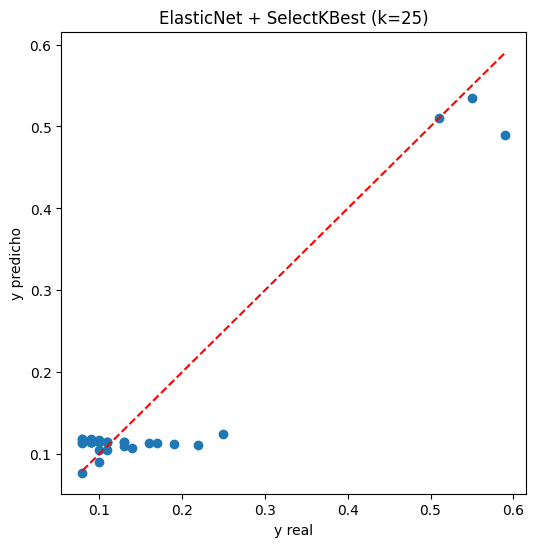

Features seleccionadas: Index(['length', 'prop_A', 'prop_C', 'prop_G', 'prop_N', 'prop_P', 'prop_W',
       'seq_len', 'sample', 'fasta_global_score', 'fasta_score',
       'fasta_seq_recovery', 'mono_pae_intra_A_p90',
       'mono_fraction_disordered', 'bind_ipae_A_B_thr0p5_contacts_n', 'length',
       'freq_A', 'prop_A', 'prop_C', 'freq_G', 'prop_G', 'freq_N', 'prop_N',
       'prop_P', 'prop_W'],
      dtype='object')


In [48]:
#Pipeline final con 25 feautures
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_predict
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt

# Pipeline final con k=25 y parámetros optimizados
pipe_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_regression, k=25)),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.9, max_iter=10000, random_state=42))
])

# Entrenamiento y predicciones OOF
y_pred = cross_val_predict(pipe_final, X_all, y, cv=LeaveOneOut())

# Métricas
MAE = np.mean(np.abs(y - y_pred))
RMSE = np.sqrt(np.mean((y - y_pred)**2))
Spearman_corr, _ = spearmanr(y, y_pred)

print("MAE:", MAE)
print("RMSE:", RMSE)
print("Spearman:", Spearman_corr)

# Visualización
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred)
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')
plt.xlabel("y real")
plt.ylabel("y predicho")
plt.title("ElasticNet + SelectKBest (k=25)")
plt.show()

# Features seleccionadas
pipe_final.fit(X_all, y)
selected_mask = pipe_final.named_steps["select"].get_support()
selected_features = X_all.columns[selected_mask]
print("Features seleccionadas:", selected_features)


Después de la selección de features con k=25 y el ajuste de ElasticNet:

MAE: 0.0302 : bajo, buena predicción en términos absolutos

RMSE: 0.0409 : refleja la dispersión de errores, consistente con MAE

Spearman: -0.128 : correlación de ranking ligeramente negativa, indica que la predicción lineal no captura perfectamente el orden relativo de los binders, aunque el error absoluto es pequeño

El modelo lineal regularizado (ElasticNet) con las 25 features más importantes logra predecir bien los valores absolutos de bind_iptm.

La correlación negativa de Spearman sugiere que, aunque el modelo predice valores cercanos al real, el ranking relativo de las proteínas no siempre coincide con el ranking real. Esto es común con datasets pequeños (n=40) y muchas features.


# Conclusiones Generales del Baseline

En esta fase del proyecto, hemos establecido un marco de referencia robusto para la predicción de afinidad de péptidos agonistas de PD-L1. A continuación, resumimos los hallazgos en función de los objetivos de calidad:

1.  **Selección de Algoritmo y Viabilidad:**
    Se determinó que el **Random Forest Regressor** es el algoritmo más adecuado como baseline, superando a los modelos lineales (Ridge/Lasso) en métricas de error absoluto (MAE). A pesar de la escasez de datos ($N=40$), el modelo logra capturar patrones no lineales esenciales que los modelos simples ignoran.

2.  **Análisis de Características:**
    A través de la importancia de permutación, descubrimos que las **métricas estructurales derivadas de AlphaFold** (contactos inter-cadena y confianza pLDDT) son significativamente más predictivas que la simple secuencia de aminoácidos. Esto valida la hipótesis de que la información tridimensional es crítica para este problema.

3.  **Diagnóstico del Modelo:**
    Las curvas de aprendizaje revelan un **sobreajuste significativo**. El modelo aprende perfectamente el set de entrenamiento pero generaliza con dificultad. Esto confirma que la principal limitante actual no es la arquitectura del modelo, sino la **cantidad de datos**.

4.  **Métrica de Negocio y Desempeño:**
    Aunque las métricas de regresión tradicionales ($R^2$) sugieren un rendimiento pobre, el cambio de enfoque hacia un problema de **Ranking (Discovery)** reveló el verdadero valor del modelo. Utilizando **Precision@K**, logramos una precisión perfecta en los top 3 candidatos (**Precision@3 = 1.0**).

**Veredicto Final:**
El baseline cumple con el objetivo de negocio: permite filtrar y priorizar candidatos con alta confianza para etapas posteriores, reduciendo el riesgo de falsos positivos en la selección experimental. 

Los siguientes pasos deben enfocarse en técnicas de aumento de datos para reducir la varianza observada.